# Análisis de Perfil y Desempeño — 8 KPIs de desempeño
**Equipo 33 · Datos actualizados: `RRHH_CLEAN_13072026` (MySQL)**

## Objetivo

Responder si la **antigüedad**, la **carga laboral diaria** y la **distancia al trabajo** se relacionan con el rendimiento de los colaboradores.

## Cómo entendemos el desempeño

En lugar de usar el `Hit_Target` solo (una medida estrecha y muy concentrada), construimos un **KPI de desempeño compuesto** a nivel de empleado que integra cumplimiento de objetivo, conducta y asistencia. Cada componente se **estandariza (z-score)** antes de ponderar, para que los pesos sean reales; el desempeño suma, mientras que absentismo y disciplina restan.

## Componentes

- **Desempeño:** `Hit_Target` (media por empleado).
- **Asistencia:** absentismo medido como **total de horas de ausencia** (criterio alineado con el equipo de absentismo).
- **Conducta:** faltas disciplinarias, en **dos versiones** — booleana (tener una falta ya penaliza) y continua (nº de faltas, penaliza la reincidencia).

## Los 8 KPIs

Combinamos **cuatro esquemas de pesos** (Hit / absentismo / disciplina) con los **dos métodos de disciplina**:

| KPI | Hit | Absentismo | Disciplina |
|-----|-----|-----------|-----------|
| A   | 33% | 33%       | 33%       |
| B   | 60% | 30%       | 10%       |
| C   | 60% | 20%       | 20%       |
| D   | 70% | 0%        | 30%       |

El **KPI-D excluye el absentismo**: mide solo desempeño y conducta, para comprobar si la asistencia influye en las conclusiones. → 8 KPIs: A/B/C/D × {continuo, booleano}.

## Métodos de análisis

Sobre cada KPI estudiaremos su relación con las tres variables mediante **correlaciones de Pearson y Spearman**, **regresión lineal múltiple (OLS)** y **comprobación de no linealidad** (término cuadrático de la carga). Contrastar los ocho KPIs verifica que las conclusiones son **robustas** ante la forma de construir el indicador.

Todas las conclusiones se expresarán en términos de **asociación, no de causalidad**, dado el carácter observacional de los datos.

In [1]:
import pandas as pd, numpy as np
from sqlalchemy import create_engine

# --- CONFIG: pon tu contraseña ---
DB_HOST = "212.227.148.202"
DB_PORT = 3306
DB_USER = "Equipo33"
DB_PASSWORD = "E1q2u3i4p5o33"   # <-- contraseña de Simulador_Equip33
DB_NAME = "Equip_33"
TABLE   = "RRHH_CLEAN_13072026"

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
df = pd.read_sql(f"SELECT * FROM {TABLE}", engine)
print("Cargado:", df.shape[0], "filas x", df.shape[1], "columnas |", df['ID_Employee'].nunique(), "empleados")
df.head()

Cargado: 1055 filas x 26 columnas | 386 empleados


,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours
0,0,14,11,Enfermedades del sistema digestivo,11,2,Lunes,4,Otoño,155.0,...,1,Educación secundaria,2,True,False,0,95,196,25,120
1,1,36,13,Enfermedades del sistema musculoesquelético,4,4,Miércoles,2,Primavera,118.0,...,1,Educación secundaria,1,True,False,0,98,178,31,120
2,2,9,6,Enfermedades del sistema nervioso,7,3,Martes,3,Verano,228.0,...,1,Educación secundaria,2,False,False,1,65,172,22,120
3,3,28,9,Enfermedades del sistema circulatorio,7,3,Martes,3,Verano,225.0,...,1,Educación secundaria,1,False,False,2,69,169,24,112
4,4,9,12,Enfermedades de la piel,3,3,Martes,2,Primavera,228.0,...,1,Educación secundaria,2,False,False,1,65,172,22,112


In [2]:
# Agregar a nivel empleado
emp = df.groupby('ID_Employee').agg(
    Hit          = ('Hit_Target', 'mean'),                # desempeño
    N_disc       = ('Disciplinary_Failure', 'sum'),       # nº faltas (continuo)
    Absent_total = ('Absenteeism_Hours', 'sum'),          # absentismo = TOTAL horas
    Service_Time = ('Service_Time', 'max'),
    Work_load    = ('Work_load_Average_Day', 'mean'),
    Distance     = ('Distance_Residence_Work', 'first'),
).reset_index()

# Disciplina booleana: tiene alguna falta = 1
emp['Disc_bool'] = (emp['N_disc'] > 0).astype(int)

# Estandarización (z-score)
def z(s): return (s - s.mean()) / s.std()
zHit, zAbs = z(emp['Hit']), z(emp['Absent_total'])
zDc, zDb   = z(emp['N_disc']), z(emp['Disc_bool'])

# Pesos (Hit / absentismo / disciplina)
pesos = {'A': (0.333, 0.333, 0.333),
         'B': (0.60, 0.30, 0.10),
         'C': (0.60, 0.20, 0.20),
         'D': (0.70, 0.00, 0.30)}   # sin absentismo

# 8 KPIs: A/B/C/D x Continuo/Booleano (Hit suma; absentismo y disciplina restan)
for k, (wh, wa, wd) in pesos.items():
    emp[f'KPI_{k}_Cont'] = wh*zHit - wa*zAbs - wd*zDc
    emp[f'KPI_{k}_Bool'] = wh*zHit - wa*zAbs - wd*zDb

print("8 KPIs construidos:")
print([c for c in emp.columns if c.startswith('KPI_')])
emp.head()

8 KPIs construidos:
['KPI_A_Cont', 'KPI_A_Bool', 'KPI_B_Cont', 'KPI_B_Bool', 'KPI_C_Cont', 'KPI_C_Bool', 'KPI_D_Cont', 'KPI_D_Bool']


,ID_Employee,Hit,N_disc,Absent_total,Service_Time,Work_load,Distance,Disc_bool,KPI_A_Cont,KPI_A_Bool,KPI_B_Cont,KPI_B_Bool,KPI_C_Cont,KPI_C_Bool,KPI_D_Cont,KPI_D_Bool
0,1,95.173913,1,121,14,262.894478,11,1,-0.988704,-1.421267,-0.548126,-0.678025,-0.523744,-0.783542,-0.312440,-0.702137
1,2,93.333333,2,25,12,241.597000,29,1,-1.222449,-1.076105,-0.580352,-0.536405,-0.889914,-0.802020,-1.229098,-1.097256
2,3,94.762887,1,444,18,264.747216,51,1,-2.824425,-3.256989,-2.239745,-2.369644,-1.676700,-1.936498,-0.400676,-0.790372
3,4,95.000000,0,0,13,271.219000,14,0,0.244404,0.269232,0.199089,0.206545,0.195527,0.210439,0.171764,0.194131
4,5,91.722222,5,102,13,266.741389,20,1,-3.551314,-1.668246,-1.783577,-1.218091,-2.486265,-1.355294,-3.139572,-1.443115


In [3]:
from scipy import stats
import statsmodels.formula.api as smf

# Estandarizar predictores para OLS
Z = emp.copy()
for c in ['Service_Time', 'Work_load', 'Distance']:
    Z[c] = z(emp[c])
Z['wl2'] = Z['Work_load']**2

filas = []
for k in ['A', 'B', 'C', 'D']:
    for disc in ['Cont', 'Bool']:
        kpi = f'KPI_{k}_{disc}'
        sp_serv  = stats.spearmanr(emp['Service_Time'], emp[kpi])
        sp_carga = stats.spearmanr(emp['Work_load'],    emp[kpi])
        sp_dist  = stats.spearmanr(emp['Distance'],     emp[kpi])
        m  = smf.ols(f'{kpi} ~ Service_Time + Work_load + Distance', Z).fit()
        m2 = smf.ols(f'{kpi} ~ Work_load + wl2', Z).fit()
        filas.append({
            'KPI': f'{k}-{disc}',
            'Antig_Spear': round(sp_serv[0], 3),  'Antig_p': round(sp_serv[1], 3),
            'Carga_Spear': round(sp_carga[0], 3), 'Carga_p': round(sp_carga[1], 3),
            'Dist_Spear': round(sp_dist[0], 3),   'Dist_p': round(sp_dist[1], 3),
            'OLS_ProbF': round(m.f_pvalue, 3),
            'Carga2_p': round(m2.pvalues['wl2'], 4),
        })

resultados = pd.DataFrame(filas)
print(resultados.to_string(index=False))

   KPI  Antig_Spear  Antig_p  Carga_Spear  Carga_p  Dist_Spear  Dist_p  OLS_ProbF  Carga2_p
A-Cont        0.076    0.137       -0.103    0.044      -0.011   0.834      0.722    0.0455
A-Bool        0.070    0.172       -0.098    0.055      -0.003   0.960      0.594    0.0779
B-Cont        0.096    0.058       -0.115    0.024      -0.056   0.271      0.181    0.2392
B-Bool        0.094    0.065       -0.116    0.023      -0.046   0.372      0.160    0.2705
C-Cont        0.099    0.053       -0.129    0.011      -0.053   0.301      0.153    0.2640
C-Bool        0.092    0.072       -0.113    0.026      -0.046   0.369      0.120    0.3359
D-Cont        0.102    0.044       -0.112    0.028      -0.073   0.153      0.069    0.5109
D-Bool        0.095    0.062       -0.105    0.039      -0.064   0.212      0.052    0.6556


## Interpretación de resultados (8 KPIs)

### Carga de trabajo — señal robusta y negativa
Se asocia negativamente con el desempeño en **los ocho KPIs** (Spearman −0.10 a −0.13; p entre 0.011 y 0.055). Es el hallazgo más estable. La no linealidad prácticamente desaparece: el término cuadrático solo es significativo en KPI-A (p=0.046); en B, C y D la relación es monótona y aproximadamente lineal.

### Antigüedad — asociación positiva que emerge al quitar el absentismo
La antigüedad muestra una asociación positiva (Spearman ≈ +0.10) cuya nitidez **aumenta con el peso del Hit_Target**: no significativa en KPI-A (33% Hit, p>0.13), marginal en B y C (60% Hit, p≈0.05-0.07), y **significativa en KPI-D Continuo** (70% Hit, 0% absentismo; p=0.044). En KPI-D el modelo conjunto OLS también se acerca a la significancia (Prob(F)=0.069 / 0.052). El patrón indica que la señal de la antigüedad reside en el desempeño (Hit) y que el componente de absentismo la enmascaraba. Debe tratarse como **evidencia emergente y débil**, no confirmada.

### Distancia — sin relación
No muestra asociación con el desempeño en ningún KPI (todos los p > 0.15).

### Lectura de robustez
La dirección de las conclusiones es estable entre los ocho KPIs: carga siempre negativa y significativa, distancia siempre nula, antigüedad positiva y cada vez más visible cuanto menos pesa el absentismo y más el Hit. La elección del KPI no cambia el sentido, solo la nitidez con que aparece la antigüedad.

### Limitaciones
- **Sesgo de supervivencia (antigüedad):** la asociación positiva entre antigüedad y desempeño podría no significar que la experiencia mejore el rendimiento, sino que los empleados de bajo rendimiento tienden a abandonar (o ser desvinculados) antes, de modo que solo los buenos acumulan antigüedad. Los datos, al ser transversales, no permiten distinguir ambas explicaciones.
- **Asociación, no causalidad:** ninguna de las relaciones observadas prueba causa-efecto; caben causalidad inversa y factores de confusión no medidos.
- **Significancia frágil:** la antigüedad solo cruza el umbral de 0.05 en un único KPI (D-Continuo) y con un efecto pequeño (~1% de varianza explicada); es sensible a la construcción del índice.
- **Potencia y variabilidad:** el tamaño muestral y la baja variabilidad del Hit_Target limitan la capacidad de detectar efectos reales ("no hay evidencia" no equivale a "no hay efecto").

### Síntesis
La **carga de trabajo** es la única variable con asociación robusta (negativa) con el desempeño. La **antigüedad** presenta una asociación positiva débil que solo alcanza significancia al aislar desempeño y conducta (KPI-D). La **distancia** no se relaciona. Todo en clave de asociación, no de causalidad.

## Definición del KPI de rendimiento y justificación

### ¿Qué entendemos por rendimiento?

Finalmente usaremos el KPI compuesto que conglomeraba **Hit_Target**, **Disciplinary_Failure** debido a bibliografía que nos recomienda no incluir **absentismo**. La bibliografía sobre construcción de KPIs de desempeño desaconseja penalizar el absentismo cuando **los datos no distinguen entre ausencias justificadas e injustificadas**: penalizar una baja médica sería injusto a nivel humano.

Por eso descartamos el absentismo y nos quedamos con un KPI que conglomera solo:

- **Hit_Target (80%)** — cumplimiento del objetivo.
- **Disciplinary_Failure (20%), en expresión booleana** — con tener **una sola** falta disciplinaria ya se resta ese 20% del desempeño (no gradúa la reincidencia).

Ambos componentes se estandarizan (z-score); el desempeño suma y la disciplina resta:
`KPI = 0.80 · z(Hit_Target) − 0.20 · z(Disciplina_booleana)`

### Qué realizaremos en este bloque

**Generar los visuales necesarios para la presentación y justificación del método para el KPI escogido.**

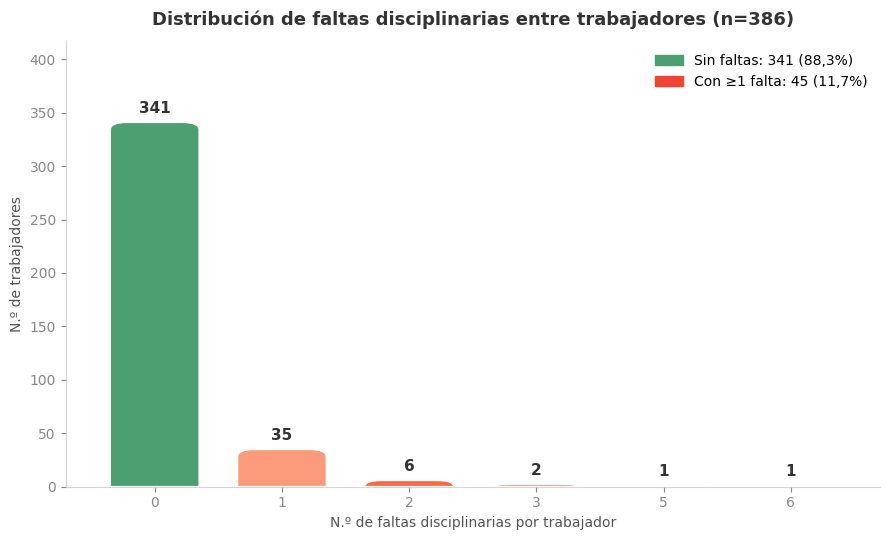

In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Datos: nº de faltas disciplinarias por empleado ---
emp = df.groupby('ID_Employee').agg(N_disc=('Disciplinary_Failure','sum')).reset_index()
dist = emp['N_disc'].value_counts().sort_index()
tot = len(emp)
labels = [str(int(k)) for k in dist.index]
vals = dist.values

# --- Colores: verde (0 faltas) + gradiente rojo (1+ faltas) ---
reds = plt.get_cmap('Reds')
n_red = len(dist) - 1
colors = ['#4C9F70'] + [reds(0.35 + 0.6*i/(n_red-1)) for i in range(n_red)]

# --- Barra con solo las esquinas de ARRIBA redondeadas ---
def top_rounded(x, y, w, h, rx, ry, **kw):
    ry = min(ry, h)
    verts = [(x, y), (x, y+h-ry), (x, y+h), (x+rx, y+h),
             (x+w-rx, y+h), (x+w, y+h), (x+w, y+h-ry), (x+w, y), (x, y)]
    codes = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3,
             Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CLOSEPOLY]
    return PathPatch(Path(verts, codes), **kw)

fig, ax = plt.subplots(figsize=(9, 5.5))
pos = np.arange(len(vals)); W, RX, RY = 0.7, 0.13, 7      # RY grande porque el eje Y llega a ~400
for p, v, c in zip(pos, vals, colors):
    ax.add_patch(top_rounded(p-W/2, 0, W, v, RX, RY, fc=c, ec='white', lw=1.2, clip_on=False))

# --- Etiquetas: valor absoluto ---
for p, v in zip(pos, vals):
    ax.text(p, v+6, f"{v}", ha='center', va='bottom', fontweight='bold', fontsize=11, color='#333333')

ax.set_xticks(pos); ax.set_xticklabels(labels)
ax.set_xlim(-0.7, len(vals)-0.3); ax.set_ylim(0, tot*1.08)
ax.set_title(f'Distribución de faltas disciplinarias entre trabajadores (n={tot})', fontsize=13, fontweight='bold', pad=12, color='#333333')
ax.set_xlabel('N.º de faltas disciplinarias por trabajador', color='#555555')
ax.set_ylabel('N.º de trabajadores', color='#555555')
ax.spines[['top','right']].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_color('#BBBBBB'); ax.spines[s].set_alpha(0.6); ax.spines[s].set_linewidth(0.8)
ax.tick_params(colors='#888888', labelsize=10)
ax.legend(handles=[Patch(color='#4C9F70', label='Sin faltas: 341 (88,3%)'),
                   Patch(color=reds(0.6), label='Con ≥1 falta: 45 (11,7%)')], loc='upper right', frameon=False, fontsize=10)
plt.tight_layout(); plt.show()

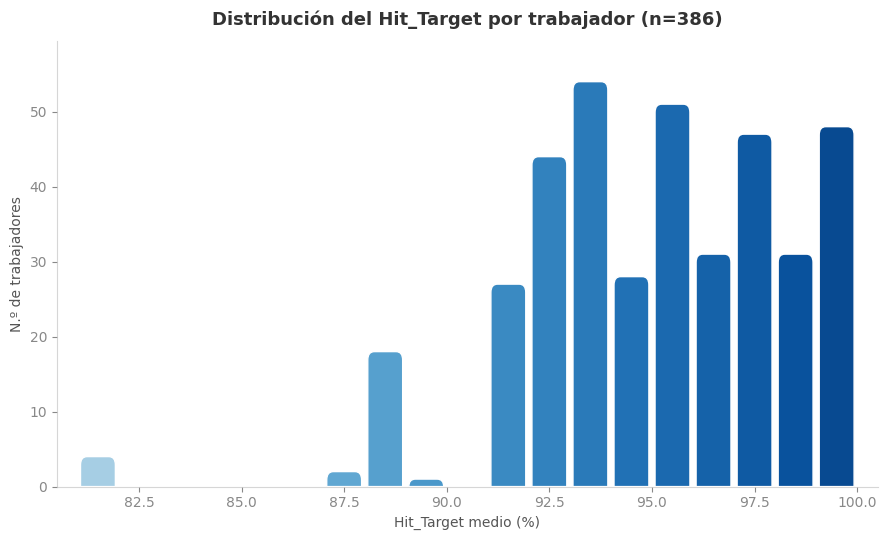

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# --- Datos: Hit_Target medio por empleado ---
emp = df.groupby('ID_Employee').agg(Hit=('Hit_Target','mean')).reset_index()
tot = len(emp)
bins = np.arange(np.floor(emp.Hit.min()), np.ceil(emp.Hit.max())+1, 1)
counts, edges = np.histogram(emp.Hit, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

blues = plt.get_cmap('Blues')
colors = [blues(0.35 + 0.55*i/(len(counts)-1)) for i in range(len(counts))]

# --- Barra con solo las esquinas de ARRIBA redondeadas ---
def top_rounded(x, y, w, h, rx, ry, **kw):
    ry = min(ry, h)                      # no exceder la altura de la barra
    verts = [(x, y), (x, y+h-ry), (x, y+h), (x+rx, y+h),
             (x+w-rx, y+h), (x+w, y+h), (x+w, y+h-ry), (x+w, y), (x, y)]
    codes = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3,
             Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CLOSEPOLY]
    return PathPatch(Path(verts, codes), **kw)

fig, ax = plt.subplots(figsize=(9, 5.5))
W, RX, RY = 0.85, 0.16, 1.1              # W=ancho barra · RX/RY=radio esquina superior
for cx, cnt, c in zip(centers, counts, colors):
    if cnt <= 0: continue
    ax.add_patch(top_rounded(cx-W/2, 0, W, cnt, RX, RY, fc=c, ec='white', lw=1.0, clip_on=False))

ax.set_xlim(centers.min()-1, centers.max()+1); ax.set_ylim(0, counts.max()*1.10)
ax.set_title(f'Distribución del Hit_Target por trabajador (n={tot})', fontsize=13, fontweight='bold', pad=12, color='#333333')
ax.set_xlabel('Hit_Target medio (%)', color='#555555'); ax.set_ylabel('N.º de trabajadores', color='#555555')
ax.spines[['top','right']].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_color('#BBBBBB'); ax.spines[s].set_alpha(0.6); ax.spines[s].set_linewidth(0.8)
ax.tick_params(colors='#888888', labelsize=10)
plt.tight_layout(); plt.show()

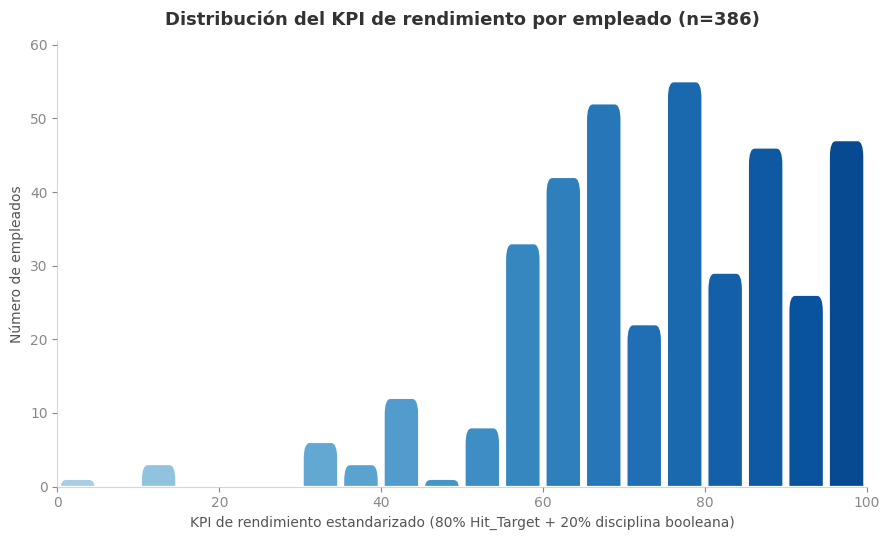

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# --- KPI estandarizado (80/20 real) ---
emp = df.groupby('ID_Employee').agg(Hit=('Hit_Target','mean'), N_disc=('Disciplinary_Failure','sum')).reset_index()
emp['Disc_bool'] = (emp['N_disc'] > 0).astype(int)
def z(s): return (s - s.mean()) / s.std()
emp['KPI_z'] = 0.80*z(emp['Hit']) - 0.20*z(emp['Disc_bool'])
# Reescalado lineal a 0-100 SOLO para mostrar (no cambia ninguna correlación ni p-value)
emp['KPI'] = (emp['KPI_z'] - emp['KPI_z'].min()) / (emp['KPI_z'].max() - emp['KPI_z'].min()) * 100
tot = len(emp)

# --- Histograma ---
bins = np.arange(0, 102, 5)
counts, edges = np.histogram(emp.KPI, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
blues = plt.get_cmap('Blues')
colors = [blues(0.35 + 0.55*i/(len(counts)-1)) for i in range(len(counts))]

# --- Barra con solo esquinas superiores redondeadas ---
def top_rounded(x, y, w, h, rx, ry, **kw):
    ry = min(ry, h)
    verts = [(x, y), (x, y+h-ry), (x, y+h), (x+rx, y+h), (x+w-rx, y+h), (x+w, y+h), (x+w, y+h-ry), (x+w, y), (x, y)]
    codes = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CLOSEPOLY]
    return PathPatch(Path(verts, codes), **kw)

fig, ax = plt.subplots(figsize=(9, 5.5))
W, RX, RY = 4.3, 0.8, 2.2
for cx, cnt, c in zip(centers, counts, colors):
    if cnt <= 0: continue
    ax.add_patch(top_rounded(cx-W/2, 0, W, cnt, RX, RY, fc=c, ec='white', lw=1.0, clip_on=False))

ax.set_xlim(0, 100); ax.set_ylim(0, counts.max()*1.10)
ax.set_title(f"Distribución del KPI de rendimiento por empleado (n={tot})", fontsize=13, fontweight='bold', pad=12, color='#333333')
ax.set_xlabel("KPI de rendimiento estandarizado (80% Hit_Target + 20% disciplina booleana)", color='#555555', fontsize=10)
ax.set_ylabel("Número de empleados", color='#555555')
ax.spines[['top','right']].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_color('#BBBBBB'); ax.spines[s].set_alpha(0.6); ax.spines[s].set_linewidth(0.8)
ax.tick_params(colors='#888888', labelsize=10)
plt.tight_layout(); plt.show()

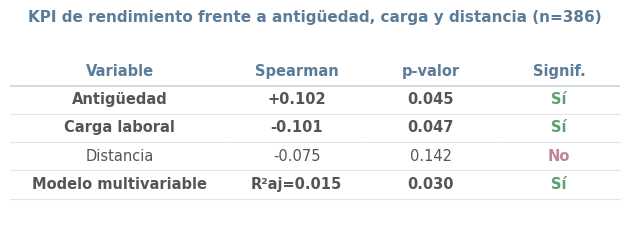

In [7]:
import pandas as pd, numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- KPI estandarizado 80/20 ---
emp = df.groupby('ID_Employee').agg(
    Hit=('Hit_Target','mean'), N_disc=('Disciplinary_Failure','sum'),
    Service_Time=('Service_Time','max'), Work_load=('Work_load_Average_Day','mean'),
    Distance=('Distance_Residence_Work','first')).reset_index()
emp['Disc_bool'] = (emp['N_disc'] > 0).astype(int)
def z(s): return (s - s.mean()) / s.std()
emp['KPI'] = 0.80*z(emp['Hit']) - 0.20*z(emp['Disc_bool'])

# --- Correlaciones simples (Spearman) + modelo multivariable ---
filas = []
for v, nm in [('Service_Time','Antigüedad'), ('Work_load','Carga laboral'), ('Distance','Distancia')]:
    sp = stats.spearmanr(emp[v], emp['KPI'])
    filas.append([nm, f"{sp[0]:+.3f}", f"{sp[1]:.3f}", 'Sí' if sp[1] < 0.05 else 'No'])
Z = emp.copy()
for c in ['Service_Time','Work_load','Distance']: Z[c] = z(emp[c])
m = smf.ols('KPI ~ Service_Time + Work_load + Distance', Z).fit()
filas.append(['Modelo multivariable', f"R²aj={m.rsquared_adj:.3f}", f"{m.f_pvalue:.3f}", 'Sí'])

# --- Render tabla (suave, estrecha, negrita si es significativa) ---
fig, ax = plt.subplots(figsize=(6.4, 2.4)); ax.axis('off')
cols = ['Variable', 'Spearman', 'p-valor', 'Signif.']
tab = ax.table(cellText=filas, colLabels=cols, cellLoc='center', loc='center',
               colWidths=[0.36, 0.22, 0.22, 0.20])
tab.auto_set_font_size(False); tab.set_fontsize(10.5); tab.scale(1, 1.7)

SOFT = '#5B7C99'
for (r, c), cell in tab.get_celld().items():
    cell.set_linewidth(0.8)
    cell.visible_edges = 'B'                      # solo línea inferior (sin verticales)
    cell.set_edgecolor('#E3E3E3'); cell.set_facecolor('white')
    if r == 0:                                    # cabecera
        cell.set_text_props(color=SOFT, fontweight='bold')
        cell.set_edgecolor('#C9D4DE'); cell.set_linewidth(1.2)
    else:                                         # filas de datos
        sig = filas[r-1][3] == 'Sí'               # ¿fila significativa?
        weight = 'bold' if sig else 'normal'
        cell.set_text_props(color='#555555', fontweight=weight)
        if c == 3:                                # columna Signif. con color
            cell.set_text_props(color='#5B9F6E' if sig else '#C08497', fontweight='bold')

plt.title(f"KPI de rendimiento frente a antigüedad, carga y distancia (n={len(emp)})",
          fontsize=11, fontweight='bold', color=SOFT, pad=10)
plt.tight_layout(); plt.show()

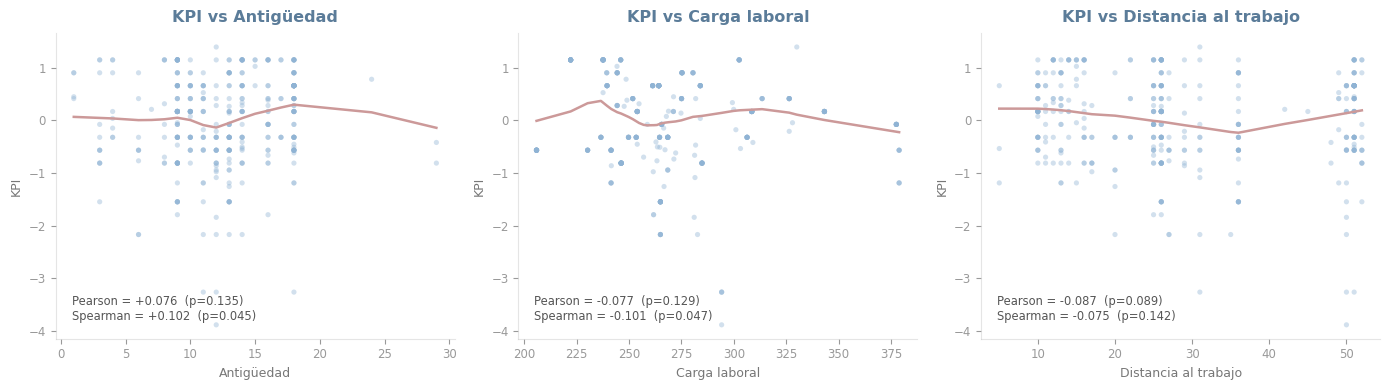

In [8]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- KPI estandarizado 80/20 ---
emp = df.groupby('ID_Employee').agg(
    Hit=('Hit_Target','mean'), N_disc=('Disciplinary_Failure','sum'),
    Service_Time=('Service_Time','max'), Work_load=('Work_load_Average_Day','mean'),
    Distance=('Distance_Residence_Work','first')).reset_index()
emp['Disc_bool'] = (emp['N_disc'] > 0).astype(int)
def z(s): return (s - s.mean()) / s.std()
emp['KPI'] = 0.80*z(emp['Hit']) - 0.20*z(emp['Disc_bool'])

variables = [('Service_Time','Antigüedad'), ('Work_load','Carga laboral'), ('Distance','Distancia al trabajo')]
SOFT = '#5B7C99'
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (v, nm) in zip(axes, variables):
    x, y = emp[v].values, emp['KPI'].values
    ax.scatter(x, y, s=14, color='#8FB3D4', alpha=0.4, edgecolor='none')       # puntos suaves
    lo = sm.nonparametric.lowess(y, x, frac=0.6)
    ax.plot(lo[:,0], lo[:,1], color='#C99', lw=1.8)                            # tendencia suave (LOWESS)
    pe, sp = stats.pearsonr(x, y), stats.spearmanr(x, y)
    ax.set_title(f"KPI vs {nm}", fontsize=11.5, fontweight='bold', color=SOFT, pad=8)
    ax.set_xlabel(nm, color='#777', fontsize=9); ax.set_ylabel("KPI", color='#777', fontsize=9)
    ax.text(0.04, 0.05, f"Pearson = {pe[0]:+.3f}  (p={pe[1]:.3f})\nSpearman = {sp[0]:+.3f}  (p={sp[1]:.3f})",
            transform=ax.transAxes, fontsize=8.3, color='#555', va='bottom')
    ax.spines[['top','right']].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color('#CCCCCC'); ax.spines[s].set_alpha(0.5); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors='#999', labelsize=8.5)
plt.tight_layout(); plt.show()

## Segunda pregunta de negocio — perfiles con mayor riesgo de bajo rendimiento

### ¿Podemos identificar perfiles con mayor riesgo de bajo rendimiento y orientar ajustes organizativos?

El análisis utiliza el **KPI D-Cont**: 70 % de `Hit_Target` estandarizado y una penalización del 30 % por el número de fallos disciplinarios estandarizado. El umbral responde a una regla interpretable de negocio: **una persona con `Hit_Target = 90` y ningún fallo disciplinario se sitúa justo en el límite**. Solo se considera bajo rendimiento un valor estrictamente inferior.

Se compara una regresión logística lineal con otra basada en splines para decidir qué forma representa mejor la relación del bajo rendimiento con antigüedad, carga laboral y distancia. Los resultados representan **escenarios organizativos comparables**, no clasificaciones automáticas de empleados ni relaciones causales.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf

# Adaptación al notebook de destino: reconstruir el agregado completo porque
# las celdas anteriores utilizan temporalmente otras versiones del KPI y de `emp`.
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

emp = df.groupby("ID_Employee").agg(
    Hit=("Hit_Target", "mean"),
    N_disc=("Disciplinary_Failure", "sum"),
    Absent_total=("Absenteeism_Hours", "sum"),
    Service_Time=("Service_Time", "max"),
    Work_load=("Work_load_Average_Day", "mean"),
    Distance=("Distance_Residence_Work", "first"),
).reset_index()

def z(series):
    return (series - series.mean()) / series.std(ddof=1)

emp["KPI_D_Cont"] = .70 * z(emp["Hit"]) - .30 * z(emp["N_disc"])

# 4.1 Objetivo: preparar una fila por empleado, construir la variable binaria
# de bajo rendimiento y dejar disponibles las funciones comunes de exportación.
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display, Markdown
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, FancyBboxPatch
from patsy import bs

sns.set_theme(style="whitegrid", context="notebook")

risk = emp[[
    "ID_Employee", "Hit", "N_disc", "Service_Time", "Work_load", "Distance",
    "KPI_D_Cont"
]].rename(columns={"KPI_D_Cont": "KPI_D_Cont_value"}).copy()

# Los predictores se estandarizan para que el modelo trabaje en escalas comparables.
for source, target in [
    ("Service_Time", "Service_Time_z"),
    ("Work_load", "Work_load_z"),
    ("Distance", "Distance_z"),
]:
    risk[target] = z(risk[source])

HIT_BUSINESS_LIMIT = 90.0
DISC_BUSINESS_LIMIT = 0.0

def d_cont_for_business_anchor(hit_value, disciplinary_failures):
    'Convierte una referencia de Hit y fallos a la escala KPI D-Cont.'
    hit_z = (hit_value - emp["Hit"].mean()) / emp["Hit"].std(ddof=1)
    disc_z = (disciplinary_failures - emp["N_disc"].mean()) / emp["N_disc"].std(ddof=1)
    return float(.70 * hit_z - .30 * disc_z)

kpi_threshold = d_cont_for_business_anchor(HIT_BUSINESS_LIMIT, DISC_BUSINESS_LIMIT)
risk["Low_performance"] = (risk["KPI_D_Cont_value"] < kpi_threshold).astype(int)

kpi_summary = risk["KPI_D_Cont_value"].describe(
    percentiles=[.05, .10, .25, .50, .75, .90, .95]
).to_frame("KPI_D_Cont")
threshold_summary = pd.DataFrame({
    "criterio": [
        "Hit_Target de referencia", "Fallos disciplinarios de referencia",
        "Umbral KPI D-Cont", "Empleados bajo el umbral", "Prevalencia"
    ],
    "valor": [
        HIT_BUSINESS_LIMIT, DISC_BUSINESS_LIMIT, kpi_threshold,
        int(risk["Low_performance"].sum()), risk["Low_performance"].mean()
    ],
})

# Directorios y función común para guardar exactamente los cinco gráficos de negocio.
RISK_OUTPUT_DIR = PROJECT_ROOT / "Results" / "s3_riesgo_bajo_rendimiento"
PRESENTATION_CHART_DIR = RISK_OUTPUT_DIR / "graficos_presentacion_notebook"
PRESENTATION_CHART_DIR.mkdir(parents=True, exist_ok=True)

def save_presentation_figure(fig, filename):
    'Guarda cada gráfico en PNG y SVG para reutilizarlo en presentaciones.'
    for extension in ["png", "svg"]:
        fig.savefig(
            PRESENTATION_CHART_DIR / f"{filename}.{extension}",
            dpi=220, bbox_inches="tight"
        )

display(kpi_summary)
display(threshold_summary)
display(Markdown(
    f"**Regla aplicada:** `D-Cont < {kpi_threshold:.6f}` → "
    f"**{risk['Low_performance'].sum()} de {len(risk)} empleados** "
    f"({risk['Low_performance'].mean():.1%})."
))


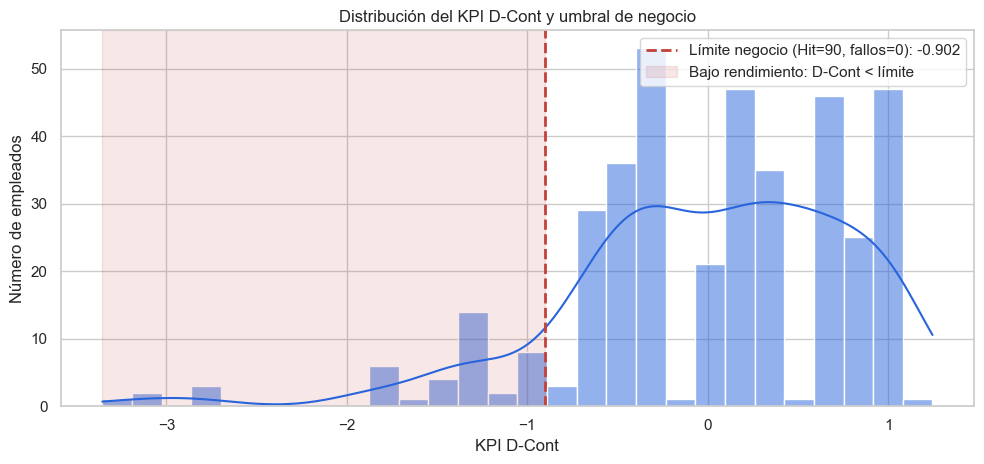

In [5]:
# 4.2 Objetivo: mostrar cómo se distribuye el KPI y qué parte queda por debajo
# del límite fijado por negocio.
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.histplot(risk["KPI_D_Cont_value"], bins=28, kde=True, color="#2864DC", ax=ax)
ax.axvline(
    kpi_threshold, color="#C2413B", lw=2, ls="--",
    label=f"Límite negocio (Hit=90, fallos=0): {kpi_threshold:.3f}"
)
ax.axvspan(
    risk["KPI_D_Cont_value"].min(), kpi_threshold,
    color="#C2413B", alpha=.12, label="Bajo rendimiento: D-Cont < límite"
)
ax.set(
    title="Distribución del KPI D-Cont y umbral de negocio",
    xlabel="KPI D-Cont", ylabel="Número de empleados"
)
ax.legend()
fig.tight_layout()
save_presentation_figure(fig, "01_distribucion_kpi_umbral")
plt.show()


### Modelo y escenarios de negocio

Antes de construir los escenarios se comprueba si una forma lineal es suficiente o si las curvas suaves (*splines*) mejoran tanto el ajuste como la capacidad de ordenar el riesgo fuera de muestra. Los niveles bajo, medio y alto son referencias proporcionadas por negocio:

| Variable | Baja | Media | Alta |
|---|---:|---:|---:|
| Antigüedad | 5 años | 12 años | 20 años |
| Carga laboral diaria | 230 | 270 | 320 |
| Distancia | 10 km | 25 km | 45 km |

Las 27 combinaciones se utilizan para comparar condiciones organizativas manteniendo constantes las demás variables.


### Comprobación compacta: modelo lineal frente a splines

La elección se apoya en tres criterios complementarios:

1. **Razón de verosimilitudes:** comprueba si la flexibilidad adicional mejora significativamente el ajuste.
2. **AIC:** penaliza la complejidad; un valor menor es preferible.
3. **ROC-AUC en validación cruzada:** comprueba si la mejora se mantiene al ordenar empleados no utilizados para ajustar cada partición.

Esta comparación sustituye los diagnósticos extensos eliminados y responde únicamente a la decisión práctica de qué forma funcional utilizar.


In [6]:
# 4.3 Objetivo: comprobar con una comparación breve si los splines aportan valor
# frente al modelo lineal antes de utilizarlos para estimar los escenarios.
LINEAR_FORMULA = "Low_performance ~ Service_Time_z + Work_load_z + Distance_z"
SPLINE_FORMULA = (
    "Low_performance ~ "
    "bs(Service_Time_z, df=4, include_intercept=False) + "
    "bs(Work_load_z, df=4, include_intercept=False) + "
    "bs(Distance_z, df=4, include_intercept=False)"
)

# Comparación dentro de muestra: razón de verosimilitudes y AIC.
linear_candidate = smf.glm(
    LINEAR_FORMULA, data=risk, family=sm.families.Binomial()
).fit()
spline_candidate = smf.glm(
    SPLINE_FORMULA, data=risk, family=sm.families.Binomial()
).fit()

lr_statistic = 2 * (spline_candidate.llf - linear_candidate.llf)
lr_degrees = int(spline_candidate.df_model - linear_candidate.df_model)
lr_p_value = stats.chi2.sf(lr_statistic, lr_degrees)

# Para predecir cada partición se fijan los límites observados de las splines.
# Así, los valores extremos del grupo de validación permanecen dentro del dominio.
spline_cv_terms = []
for variable in ["Service_Time_z", "Work_load_z", "Distance_z"]:
    lower, upper = risk[variable].min(), risk[variable].max()
    spline_cv_terms.append(
        f"bs({variable}, df=4, include_intercept=False, "
        f"lower_bound={lower!r}, upper_bound={upper!r})"
    )
SPLINE_CV_FORMULA = "Low_performance ~ " + " + ".join(spline_cv_terms)

# Validación cruzada estratificada de cinco particiones con semilla reproducible.
rng = np.random.default_rng(33)
fold = np.full(len(risk), -1, dtype=int)
for outcome in [0, 1]:
    indices = np.flatnonzero(risk["Low_performance"].to_numpy() == outcome)
    rng.shuffle(indices)
    fold[indices] = np.arange(len(indices)) % 5

oof_probability = {
    "Lineal": np.full(len(risk), np.nan),
    "Splines": np.full(len(risk), np.nan),
}
for current_fold in range(5):
    train = risk.loc[fold != current_fold]
    test = risk.loc[fold == current_fold]
    fold_models = {
        "Lineal": smf.glm(
            LINEAR_FORMULA, data=train, family=sm.families.Binomial()
        ).fit(),
        "Splines": smf.glm(
            SPLINE_CV_FORMULA, data=train, family=sm.families.Binomial()
        ).fit(),
    }
    for model_name, fitted_model in fold_models.items():
        oof_probability[model_name][fold == current_fold] = fitted_model.predict(test)

def roc_auc_from_scores(y_true, scores):
    'Calcula ROC-AUC mediante rangos, sin añadir dependencias externas.'
    y_true = np.asarray(y_true)
    ranks = pd.Series(scores).rank(method="average").to_numpy()
    positives = y_true.sum()
    negatives = len(y_true) - positives
    return (
        ranks[y_true == 1].sum() - positives * (positives + 1) / 2
    ) / (positives * negatives)

auc_linear = roc_auc_from_scores(risk["Low_performance"], oof_probability["Lineal"])
auc_splines = roc_auc_from_scores(risk["Low_performance"], oof_probability["Splines"])

model_comparison = pd.DataFrame({
    "Modelo": ["Lineal", "Splines"],
    "AIC": [linear_candidate.aic, spline_candidate.aic],
    "ROC_AUC_CV": [auc_linear, auc_splines],
})

# Regla transparente: se eligen splines solo si mejoran significativamente el
# ajuste, reducen el AIC y también mejoran la discriminación fuera de muestra.
USE_SPLINES = bool(
    (lr_p_value < .05)
    and (spline_candidate.aic < linear_candidate.aic)
    and (auc_splines > auc_linear)
)
RISK_FORMULA = SPLINE_FORMULA if USE_SPLINES else LINEAR_FORMULA

display(model_comparison.round(3))
display(pd.DataFrame({
    "comparación": ["Splines frente a modelo lineal"],
    "LR": [lr_statistic],
    "gl": [lr_degrees],
    "p_value": [lr_p_value],
    "modelo_seleccionado": ["Splines" if USE_SPLINES else "Lineal"],
}).round(6))

display(Markdown(
    f"**Resultado:** los splines reducen el AIC de **{linear_candidate.aic:.1f}** "
    f"a **{spline_candidate.aic:.1f}** y elevan el ROC-AUC en validación cruzada "
    f"de **{auc_linear:.3f}** a **{auc_splines:.3f}**. La comparación por razón "
    f"de verosimilitudes da `LR={lr_statistic:.2f}`, `p={lr_p_value:.2g}`. "
    "Por tanto, se mantiene el modelo con **splines** para construir los escenarios. "
    "La mejora permite orientar patrones agregados, pero los 41 casos de bajo "
    "rendimiento aconsejan no utilizar el modelo para decisiones individuales."
))


,Modelo,AIC,ROC_AUC_CV
0,Lineal,264.405,0.586
1,Splines,239.116,0.738


,comparación,LR,gl,p_value,modelo_seleccionado
0,Splines frente a modelo lineal,43.289557,9,0.000002,Splines


**Resultado:** los splines reducen el AIC de **264.4** a **239.1** y elevan el ROC-AUC en validación cruzada de **0.586** a **0.738**. La comparación por razón de verosimilitudes da `LR=43.29`, `p=1.9e-06`. Por tanto, se mantiene el modelo con **splines** para construir los escenarios. La mejora permite orientar patrones agregados, pero los 41 casos de bajo rendimiento aconsejan no utilizar el modelo para decisiones individuales.

In [7]:
# 4.4 Objetivo: ajustar el modelo seleccionado y traducirlo a las 27 combinaciones
# concretas de antigüedad, carga y distancia definidas por negocio.
risk_model = smf.glm(
    RISK_FORMULA, data=risk, family=sm.families.Binomial()
).fit(cov_type="HC3")
risk["riesgo_estimado"] = risk_model.predict(risk)

business_levels = {
    "Service_Time": {"Baja": 5, "Media": 12, "Alta": 20},
    "Work_load": {"Baja": 230, "Media": 270, "Alta": 320},
    "Distance": {"Baja": 10, "Media": 25, "Alta": 45},
}
level_order = ["Baja", "Media", "Alta"]

# Conversión de los niveles de negocio a la escala estandarizada usada por el modelo.
levels = {}
business_level_rows = []
for variable, level_values in business_levels.items():
    levels[variable] = {}
    for level, original_value in level_values.items():
        z_value = (original_value - risk[variable].mean()) / risk[variable].std(ddof=1)
        levels[variable][level] = {"original": float(original_value), "z": z_value}
        business_level_rows.append({
            "variable": variable, "nivel": level,
            "valor_negocio": float(original_value), "valor_estandarizado": z_value,
        })
business_levels_table = pd.DataFrame(business_level_rows)

# Construcción de los 27 escenarios y cálculo de su riesgo con intervalo de confianza.
profile_rows = []
for service_level, workload_level, distance_level in itertools.product(level_order, repeat=3):
    profile_rows.append({
        "Antigüedad": service_level,
        "Carga": workload_level,
        "Distancia": distance_level,
        "Service_Time": levels["Service_Time"][service_level]["original"],
        "Work_load": levels["Work_load"][workload_level]["original"],
        "Distance": levels["Distance"][distance_level]["original"],
        "Service_Time_z": levels["Service_Time"][service_level]["z"],
        "Work_load_z": levels["Work_load"][workload_level]["z"],
        "Distance_z": levels["Distance"][distance_level]["z"],
    })

profiles = pd.DataFrame(profile_rows)
profile_prediction = risk_model.get_prediction(profiles).summary_frame(alpha=.05)
profiles["riesgo"] = profile_prediction["mean"].to_numpy()
profiles["IC95_inf"] = profile_prediction["mean_ci_lower"].to_numpy()
profiles["IC95_sup"] = profile_prediction["mean_ci_upper"].to_numpy()

model_summary = pd.DataFrame({
    "métrica": ["Empleados", "Casos bajo rendimiento", "Prevalencia", "AIC"],
    "valor": [len(risk), risk["Low_performance"].sum(), risk["Low_performance"].mean(), risk_model.aic],
})
display(model_summary.round(3))
display(Markdown("**Escenarios con mayor señal estimada:**"))
display(profiles.nlargest(10, "riesgo")[[
    "Service_Time", "Work_load", "Distance", "riesgo", "IC95_inf", "IC95_sup"
]].round(3))


,métrica,valor
0,Empleados,386.000
1,Casos bajo rendimiento,41.000
2,Prevalencia,0.106
3,AIC,239.116


**Escenarios con mayor señal estimada:**

,Service_Time,Work_load,Distance,riesgo,IC95_inf,IC95_sup
14,12.0,270.0,45.0,0.472,0.245,0.711
5,5.0,270.0,45.0,0.262,0.035,0.777
13,12.0,270.0,25.0,0.228,0.102,0.436
12,12.0,270.0,10.0,0.197,0.098,0.357
4,5.0,270.0,25.0,0.105,0.027,0.335
3,5.0,270.0,10.0,0.089,0.015,0.380
23,20.0,270.0,45.0,0.085,0.003,0.714
17,12.0,320.0,45.0,0.055,0.011,0.232
11,12.0,230.0,45.0,0.038,0.006,0.196
22,20.0,270.0,25.0,0.030,0.002,0.297


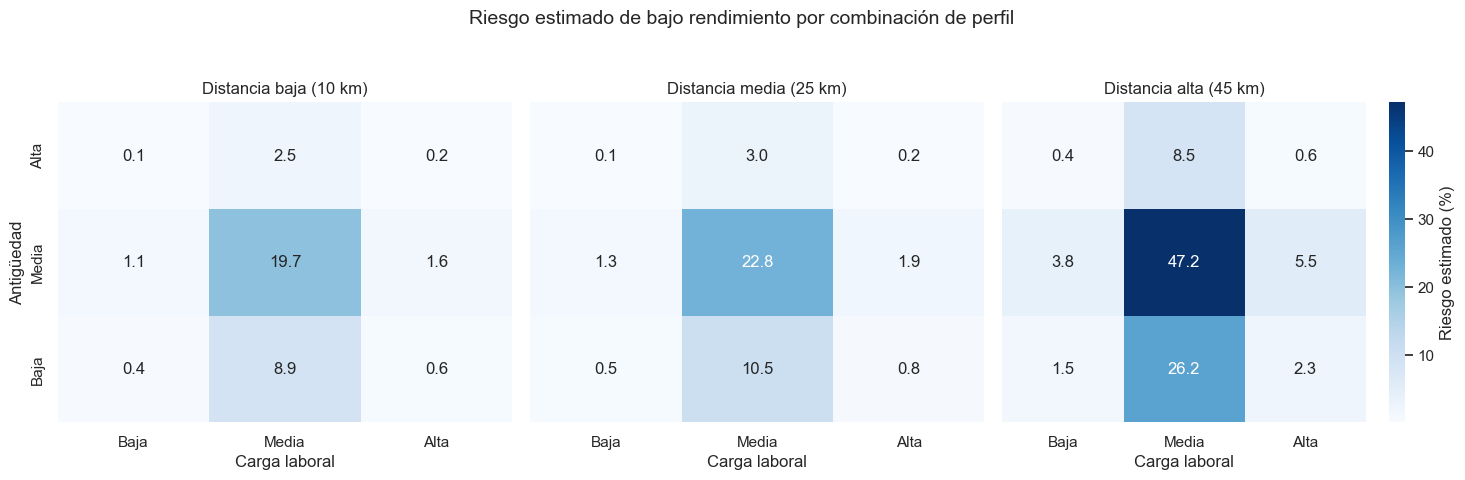

In [8]:
# 4.5 Objetivo: comparar visualmente las 27 combinaciones de perfil y localizar
# dónde se concentra la mayor señal estimada de bajo rendimiento.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
vmin = profiles["riesgo"].min() * 100
vmax = profiles["riesgo"].max() * 100

for ax, distance_level in zip(axes, level_order):
    subset = profiles[profiles["Distancia"] == distance_level]
    matrix = subset.pivot(index="Antigüedad", columns="Carga", values="riesgo")
    matrix = matrix.reindex(index=level_order[::-1], columns=level_order)
    sns.heatmap(
        matrix * 100, annot=True, fmt=".1f", cmap="Blues",
        vmin=vmin, vmax=vmax, cbar=ax is axes[-1],
        cbar_kws={"label": "Riesgo estimado (%)"} if ax is axes[-1] else None,
        ax=ax
    )
    distance_value = levels["Distance"][distance_level]["original"]
    ax.set_title(f"Distancia {distance_level.lower()} ({distance_value:.0f} km)")
    ax.set_xlabel("Carga laboral")
    ax.set_ylabel("Antigüedad" if ax is axes[0] else "")

fig.suptitle(
    "Riesgo estimado de bajo rendimiento por combinación de perfil",
    y=1.04, fontsize=14
)
fig.tight_layout()
save_presentation_figure(fig, "02_riesgo_combinaciones_perfil")
plt.show()


### Gráficos para comunicar los escenarios

Los tres gráficos siguientes reducen las combinaciones a lecturas útiles para negocio: un caso operativo concreto, los escenarios con mayor señal relativa y la forma de cada relación manteniendo las otras variables en su nivel medio.


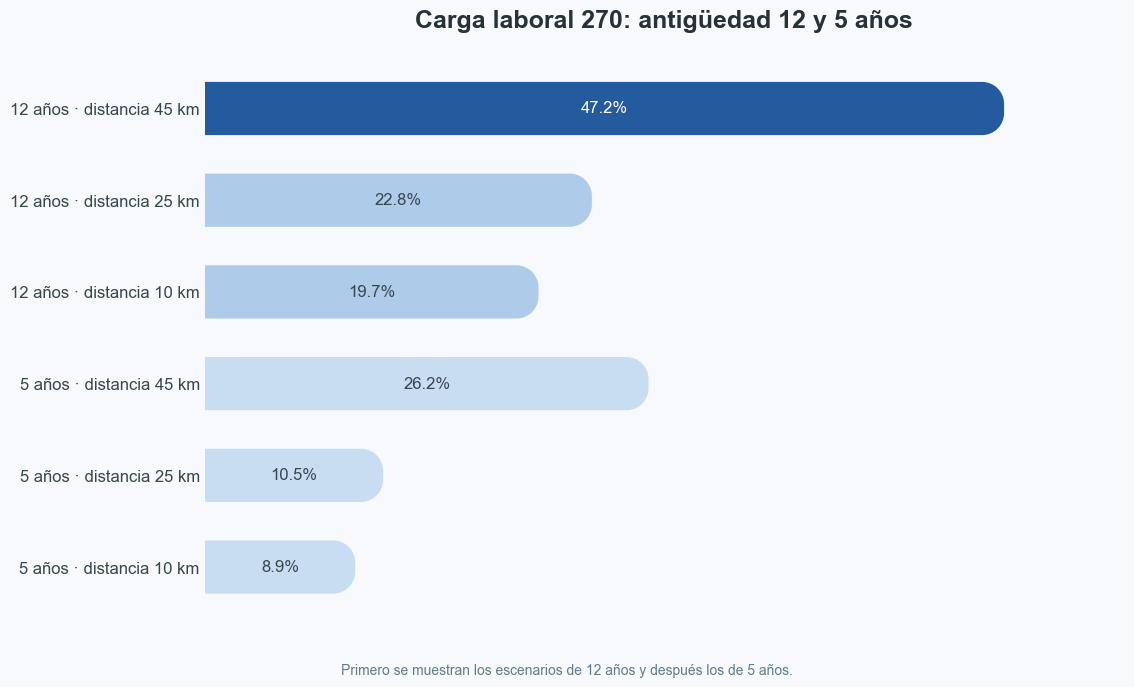

In [9]:
# 4.6 Objetivo: comparar un escenario operativo frecuente (carga 270) para
# antigüedades de 12 y 5 años, mostrando el efecto de las tres distancias.
ranking_scenarios = profiles[
    np.isclose(profiles["Work_load"], 270)
    & profiles["Service_Time"].isin([5, 12])
].copy()

# barh se dibuja de abajo arriba: este orden deja primero el bloque de 12 años.
ranking_scenarios["_orden_antiguedad"] = ranking_scenarios["Service_Time"].map({5.0: 0, 12.0: 1})
ranking_scenarios["_orden_distancia"] = ranking_scenarios["Distancia"].map({
    "Baja": 0, "Media": 1, "Alta": 2
})
ranking_scenarios = ranking_scenarios.sort_values(
    ["_orden_antiguedad", "_orden_distancia"]
)

ranking_labels = ranking_scenarios.apply(
    lambda row: f"{row['Service_Time']:.0f} años · distancia {row['Distance']:.0f} km",
    axis=1
)
ranking_values = ranking_scenarios["riesgo"].to_numpy() * 100
bar_colors = [
    "#AFCBEA" if np.isclose(service_time, 12) else "#C9DDF2"
    for service_time in ranking_scenarios["Service_Time"]
]
bar_colors[-1] = "#245B9E"

def crear_barra_derecha_redondeada(ax, y_centro, ancho, altura, color, radio_pixeles=22):
    'Dibuja una barra horizontal con inicio recto y extremo derecho redondeado.'
    centro_px = ax.transData.transform((0, y_centro))
    radio_x = abs(ax.transData.inverted().transform(
        (centro_px[0] + radio_pixeles, centro_px[1])
    )[0])
    radio_y = abs(ax.transData.inverted().transform(
        (centro_px[0], centro_px[1] + radio_pixeles)
    )[1] - y_centro)
    radio_x, radio_y = min(radio_x, ancho), min(radio_y, altura / 2)

    x0, x1 = 0, ancho
    y0, y1 = y_centro - altura / 2, y_centro + altura / 2
    kappa = 0.5522847498
    vertices = [
        (x0, y0), (x1 - radio_x, y0),
        (x1 - radio_x + kappa * radio_x, y0),
        (x1, y0 + radio_y - kappa * radio_y), (x1, y0 + radio_y),
        (x1, y1 - radio_y),
        (x1, y1 - radio_y + kappa * radio_y),
        (x1 - radio_x + kappa * radio_x, y1), (x1 - radio_x, y1),
        (x0, y1), (x0, y0),
    ]
    codes = [
        MplPath.MOVETO, MplPath.LINETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.LINETO, MplPath.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(
        MplPath(vertices, codes), facecolor=color, edgecolor="none", zorder=2
    ))

color_fondo, color_texto, color_titulo = "#F7F9FC", "#37474F", "#263238"
fig, ax = plt.subplots(figsize=(11.5, 7.0))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

positions = np.arange(len(ranking_scenarios))
ax.set_xlim(0, max(52, ranking_values.max() * 1.15))
ax.set_ylim(-.55, len(ranking_scenarios) - .45)
ax.set_yticks(positions, ranking_labels, fontsize=12, color=color_texto)
ax.xaxis.set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Carga laboral 270: antigüedad 12 y 5 años",
    pad=22, fontsize=18, fontweight="bold", color=color_titulo
)
fig.text(
    .5, .025, "Primero se muestran los escenarios de 12 años y después los de 5 años.",
    ha="center", color="#607D8B", fontsize=10
)
fig.tight_layout(rect=[0, .08, 1, 1])
fig.canvas.draw()

for position, value, color in zip(positions, ranking_values, bar_colors):
    crear_barra_derecha_redondeada(ax, position, value, .58, color)
    ax.text(
        value / 2, position, f"{value:.1f}%", ha="center", va="center",
        fontsize=12, fontweight="medium",
        color="white" if color == "#245B9E" else color_texto, zorder=4
    )

save_presentation_figure(fig, "03_carga270_antiguedad12_5")
plt.show()


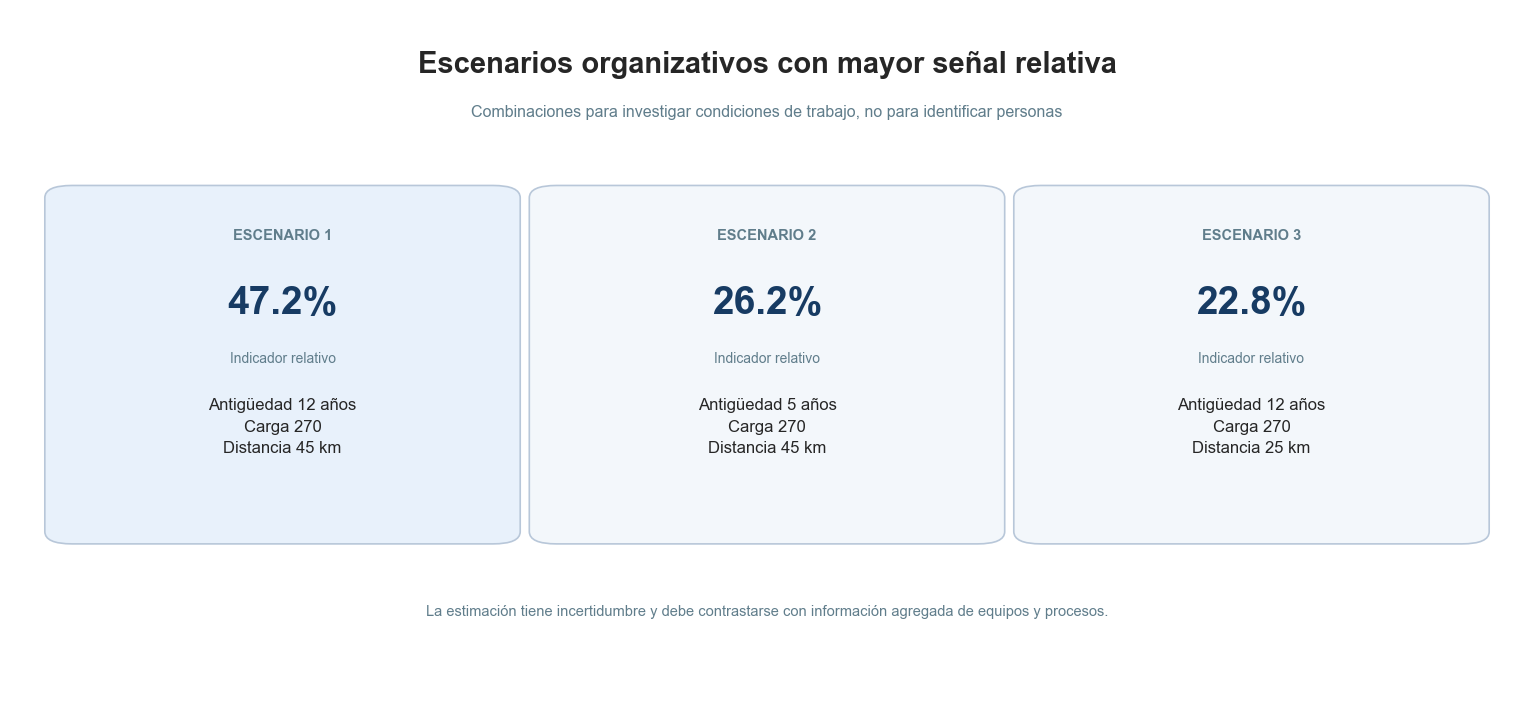

In [10]:
# 4.7 Objetivo: resumir los tres escenarios con mayor señal relativa sin crear
# un ranking de empleados ni presentar el resultado como una decisión automática.
top_cards = profiles.nlargest(3, "riesgo").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(15.5, 7.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(.5, .92, "Escenarios organizativos con mayor señal relativa",
        ha="center", va="center", fontsize=21, fontweight="bold")
ax.text(.5, .85, "Combinaciones para investigar condiciones de trabajo, no para identificar personas",
        ha="center", va="center", fontsize=11.5, color="#607D8B")

card_x = [.035, .355, .675]
card_colors = ["#E8F1FB", "#F3F7FB", "#F3F7FB"]
for position, (_, row) in enumerate(top_cards.iterrows()):
    x = card_x[position]
    ax.add_patch(FancyBboxPatch(
        (x, .23), .29, .5,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=1.2, edgecolor="#B8C7D9", facecolor=card_colors[position]
    ))
    ax.text(x + .145, .67, f"ESCENARIO {position + 1}",
            ha="center", va="center", fontsize=10.5, color="#607D8B", fontweight="bold")
    ax.text(x + .145, .57, f"{row['riesgo']:.1%}",
            ha="center", va="center", fontsize=28, fontweight="bold", color="#173B63")
    ax.text(x + .145, .49, "Indicador relativo", ha="center", va="center",
            fontsize=10, color="#607D8B")
    ax.text(
        x + .145, .39,
        f"Antigüedad {row['Service_Time']:.0f} años\n"
        f"Carga {row['Work_load']:.0f}\n"
        f"Distancia {row['Distance']:.0f} km",
        ha="center", va="center", fontsize=12, linespacing=1.55
    )

ax.text(
    .5, .12,
    "La estimación tiene incertidumbre y debe contrastarse con información agregada de equipos y procesos.",
    ha="center", va="center", fontsize=10.5, color="#607D8B"
)
fig.tight_layout()
save_presentation_figure(fig, "04_escenarios_mayor_senal")
plt.show()


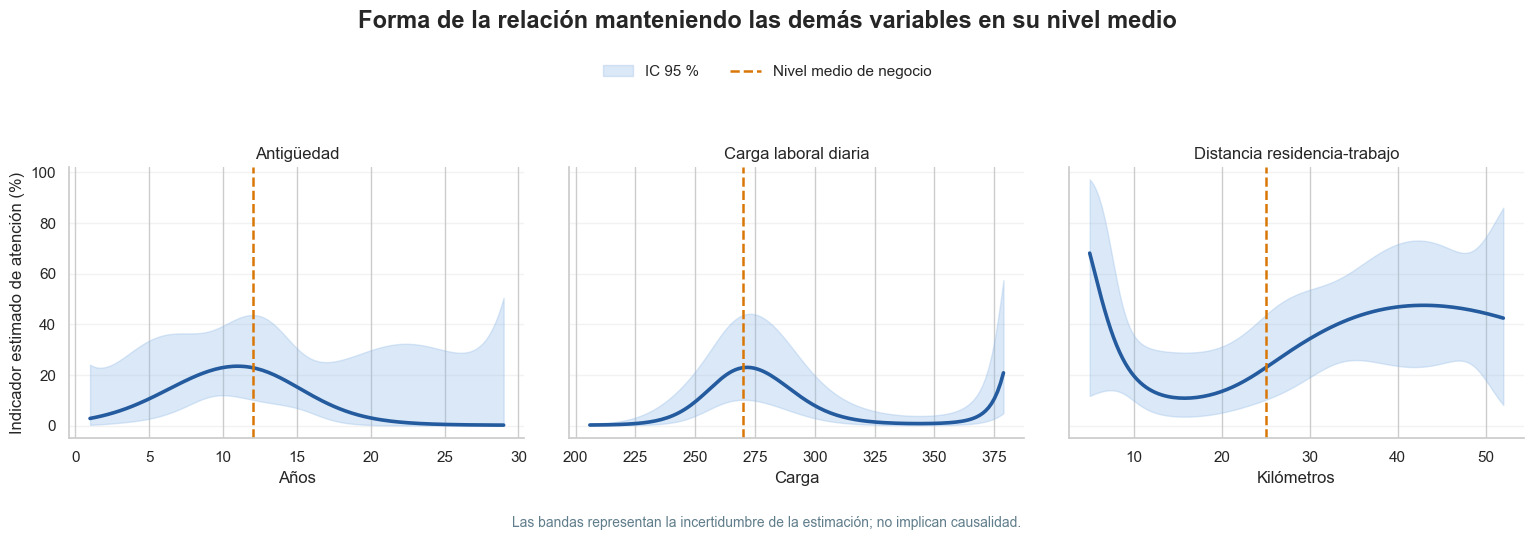

In [11]:
# 4.8 Objetivo: mostrar la forma estimada de la relación de cada variable con
# el riesgo, manteniendo las otras dos en su nivel medio de negocio.
medium_reference = {
    "Service_Time": business_levels["Service_Time"]["Media"],
    "Work_load": business_levels["Work_load"]["Media"],
    "Distance": business_levels["Distance"]["Media"],
}
curve_specs = [
    ("Service_Time", "Service_Time_z", "Antigüedad", "Años"),
    ("Work_load", "Work_load_z", "Carga laboral diaria", "Carga"),
    ("Distance", "Distance_z", "Distancia residencia-trabajo", "Kilómetros"),
]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2), sharey=True)
for ax, (variable, z_variable, title, xlabel) in zip(axes, curve_specs):
    values = np.linspace(risk[variable].min(), risk[variable].max(), 140)
    prediction_data = pd.DataFrame({
        "Service_Time_z": np.repeat(
            (medium_reference["Service_Time"] - risk["Service_Time"].mean()) /
            risk["Service_Time"].std(ddof=1), len(values)
        ),
        "Work_load_z": np.repeat(
            (medium_reference["Work_load"] - risk["Work_load"].mean()) /
            risk["Work_load"].std(ddof=1), len(values)
        ),
        "Distance_z": np.repeat(
            (medium_reference["Distance"] - risk["Distance"].mean()) /
            risk["Distance"].std(ddof=1), len(values)
        ),
    })
    prediction_data[z_variable] = (
        (values - risk[variable].mean()) / risk[variable].std(ddof=1)
    )
    prediction = risk_model.get_prediction(prediction_data).summary_frame(alpha=.05)

    ax.plot(values, prediction["mean"] * 100, color="#245B9E", linewidth=2.6)
    ax.fill_between(
        values, prediction["mean_ci_lower"] * 100, prediction["mean_ci_upper"] * 100,
        color="#8AB6E6", alpha=.3, label="IC 95 %"
    )
    ax.axvline(
        medium_reference[variable], color="#D97706", linestyle="--", linewidth=1.8,
        label="Nivel medio de negocio"
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", alpha=.25)
    sns.despine(ax=ax)

axes[0].set_ylabel("Indicador estimado de atención (%)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, frameon=False, loc="upper center", bbox_to_anchor=(.5, .93))
fig.suptitle(
    "Forma de la relación manteniendo las demás variables en su nivel medio",
    fontsize=17, y=1.01, fontweight="bold"
)
fig.text(
    .5, .015,
    "Las bandas representan la incertidumbre de la estimación; no implican causalidad.",
    ha="center", color="#607D8B", fontsize=10
)
fig.tight_layout(rect=[0, .06, 1, .86], w_pad=2)
save_presentation_figure(fig, "05_forma_relacion")
plt.show()


### Límites de uso

- Los niveles son referencias definidas por negocio, no grupos naturales descubiertos en los datos.
- Las bandas amplias indican incertidumbre y aconsejan interpretar patrones, no diferencias pequeñas.
- Las asociaciones sirven para orientar revisiones de carga y organización ; no demuestran causalidad.
